In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from cycler import cycler

import astropy.units as u
from astropy.units import Quantity
import astropy.constants as const
from astropy.coordinates import SkyCoord
from scipy import integrate
from scipy.special import erfc, erf
from scipy.optimize import curve_fit
from scipy.stats import gaussian_kde

from tqdm import tqdm
import multiprocess as mp
from functools import partial
from pathlib import Path
import itertools
import copy
import warnings
import collections

from histpy import Histogram, Axes, Axis, HealpixAxis
import healpy as hp
import mhealpy as mhp
from mhealpy import HealpixMap, HealpixBase
from scoords import Attitude, SpacecraftFrame

from cosipy.response import FullDetectorResponse, DetectorResponse, PointSourceResponse
from cosipy import UnBinnedData, BinnedData, test_data
from FullDetectorResponseNew import FullDetectorResponse
from DetectorResponseNew import DetectorResponse
from cosipy.spacecraftfile import SpacecraftFile

from astromodels import PointSource, Parameter
from lmfit.models import gaussian
from threeML import Model, Powerlaw, Gaussian, Constant, Band
from threeML import PluginPrototype, Model, JointLikelihood, DataList
from threeML.utils.statistics.likelihood_functions import poisson_log_likelihood_ideal_bkg

# Matplotlib style template
## For black, set #000000. For navy, set #002060
defaultcolor = '#002060'
plt.rcParams.update(plt.rcParamsDefault)
plt.rcParams.update({'text.color': defaultcolor, 'axes.labelcolor': defaultcolor, 
                     'xtick.color': defaultcolor, 'ytick.color': defaultcolor,
                     'axes.prop_cycle': cycler(color=['orange', 'limegreen', 'b', 'r']),
                     'font.family':'serif', 'font.serif': 'Times New Roman',
                     'font.size': 22, 'lines.linewidth': 3,
                     'figure.figsize': (9.6, 5.4), 'figure.dpi': 100})

DATA_DIR = Path('/Users/penguin/Documents/Research/COSI/COSIpy/docs/DC3/')
response_path = DATA_DIR / 'data/responses/Response44Ti.o4.e1154_1160.s9607532021290.m1215.filtered.nonsparse.binnedimaging.imagingresponse_nside16.area.h5'
# response_path = DATA_DIR / 'data/responses/SMEXv12.44Ti.HEALPix04.E_1143_1171keV.binnedimaging.imagingresponse.nonsparse_nside16.area.h5'

08:00:04 WARNING   The naima package is not available. Models that depend on it will not be         ]8;id=26282;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=777035;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py#48\48]8;;\
                  available                                                                                        

         WARNING   The GSL library or the pygsl wrapper cannot be loaded. Models that depend on it  ]8;id=467647;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=842847;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py#69\69]8;;\
                  will not be available.                                                                           

/Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/numba/core/decorators.py:262: NumbaDeprecationWarning: numba.generated_jit is deprecated. Please see the documentation at: https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-generated-jit for more information and advice on a suitable replacement.
  warnings.warn(msg, NumbaDeprecationWarning)


         WARNING   The ebltable package is not available. Models that depend on it will not be     ]8;id=664769;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/absorption.py\absorption.py]8;;\:]8;id=904275;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/absorption.py#33\33]8;;\
                  available                                                                                        

/Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/numba/core/decorators.py:262: NumbaDeprecationWarning: numba.generated_jit is deprecated. Please see the documentation at: https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-generated-jit for more information and advice on a suitable replacement.
  warnings.warn(msg, NumbaDeprecationWarning)


...

         WARNING   Could not import plugin FermiLATLike.py. Do you have the relative instrument     ]8;id=786547;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=451266;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py#144\144]8;;\
                  software installed and configured?                                                               

08:00:06 WARNING   No fermitools installed                                              ]8;id=460332;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py\lat_transient_builder.py]8;;\:]8;id=83901;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py#44\44]8;;\

         WARNING   Env. variable OMP_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=109928;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=193740;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py#387\387]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable MKL_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=379671;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=816927;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py#387\387]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable NUMEXPR_NUM_THREADS is not set. Please set it to 1 for optimal     ]8;id=977215;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=995209;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py#387\387]8;;\
                  performances in 3ML                                                                              

In [2]:
pix = 0

with FullDetectorResponse.open(response_path) as f:
    print(f.__dict__)
    dr = f[pix]

{'_file': <HDF5 file "Response44Ti.o4.e1154_1160.s9607532021290.m1215.filtered.nonsparse.binnedimaging.imagingresponse_nside16.area.h5" (mode r)>, '_drm': <HDF5 group "/DRM" (2 members)>, '_unit': Unit("cm2"), '_sparse': False, '_axes': <histpy.axes.Axes object at 0x32f81c610>, '_pix_rangesets': None, '_pix_rangesets_argsort': None, '_uniq': None, '_scheme': 'RING', '_order': 4, '_coordsys': <SpacecraftFrame Frame (attitude=None, obstime=None, location=None)>, '_npix_ratio_max': 1125899906842624}


#### RSP Investigation

In [5]:
with FullDetectorResponse.open(response_path) as f:
    rsp = np.array(f._file['DRM']['CONTENTS'])

In [94]:
(rsp.sum(axis=(2,3,4)) / dr.get_effective_area().contents.value)

array([[1.        ],
       [1.00032745],
       [0.99946126],
       ...,
       [0.14320536],
       [0.1576296 ],
       [0.15834823]])

Text(0.5, 1.0, 'Healpix Map [2000:]')

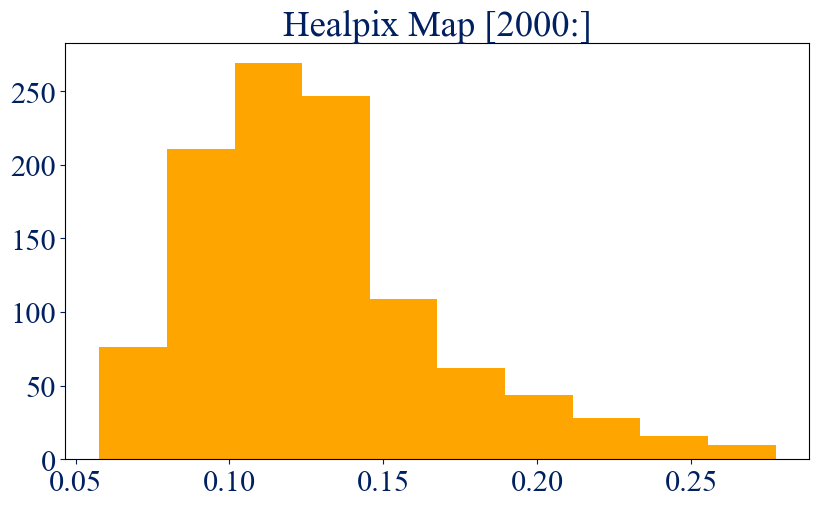

In [41]:
plt.hist((rsp.sum(axis=(2,3,4)) / dr.get_effective_area().contents)[2000:])
plt.title('Healpix Map [2000:]')

### Data

In [3]:
name = 'CasAfullyresolved'
point_source = UnBinnedData(DATA_DIR / '44Ti/inputs.yaml')
data = point_source.get_dict_from_fits(DATA_DIR / f'44Ti/sources/{name}_3months_unbinned_data_filtered_with_SAAcut.fits')

target_coord = SkyCoord.from_name('Cas A').galactic
l = target_coord.l.value
b = target_coord.b.value

In [4]:
bg = UnBinnedData(DATA_DIR / '44Ti/inputs.yaml')
bg_filepath = DATA_DIR / 'data/backgrounds/unbinned/AlbedoPhotons_44Ti.fits'        # Events with energy values between 1100 and 1200 keV only
bg_dict = bg.get_dict_from_fits(bg_filepath)

In [5]:
bg_kde = gaussian_kde(bg_dict['Energies'])

#### Testing KDE

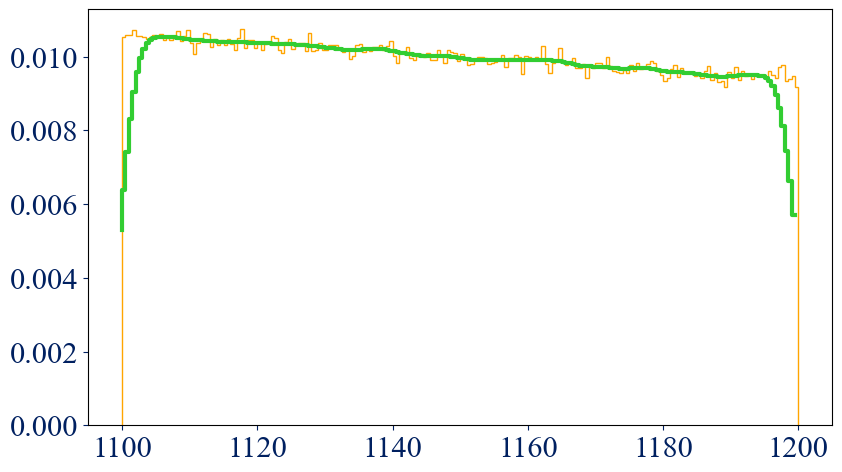

In [6]:
plt.hist(bg_dict['Energies'], bins=200, density=True, histtype='step')
x = np.arange(1100, 1200, 0.5)
plt.step(x, bg_kde(x))
plt.show()

In [7]:
bg_ang_rot = rot_custom(bg_dict['Chi galactic'], bg_dict['Psi galactic'], lonlat=True)
background_data = np.array([bg_dict['Energies'], bg_dict['Phi'], bg_ang_rot[1], bg_ang_rot[0]])

NameError: name 'rot_custom' is not defined

In [ ]:
background_kde = gaussian_kde(background_data[[0,3],:])

In [ ]:
idx = 1000
background_kde([bg_dict['Energies'][idx], ang_rot[0][idx]])#, bg_ang_rot[1][idx], bg_ang_rot[0][idx]])

array([2.86126096e-05])

In [32]:
import datetime
datetime.datetime.now().strftime("%Y%m%d_%H%M%S")

'20250829_093930'

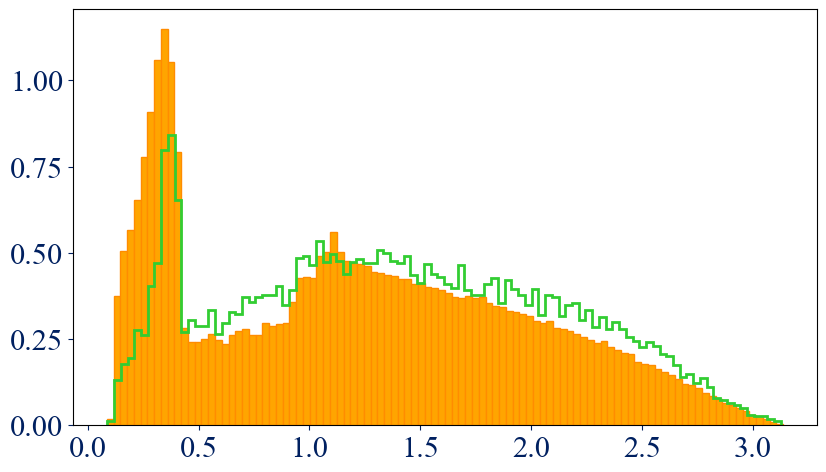

In [25]:
key = 'Phi'
indices = (bg_dict['Energies'] > 1140) & (bg_dict['Energies'] < 1180)
plt.hist(bg_dict[key][indices], bins=100, density=True, edgecolor='darkorange')
indices = (data['Energies'] > 1140) & (data['Energies'] < 1180)
plt.hist(data[key][indices], bins=100, density=True, histtype='step', lw=2)
plt.show()

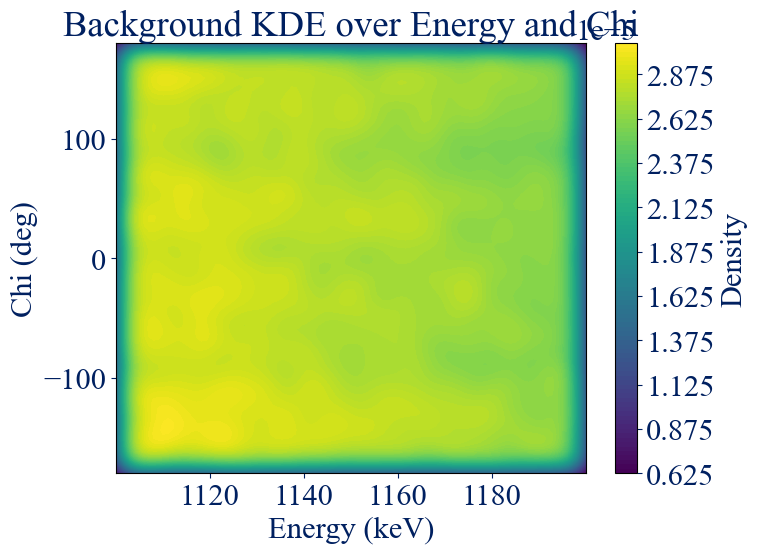

In [143]:
# Define grid over energy and chi. These axes have the greatest discriminating power.
energy_min, energy_max = background_data[0].min(), background_data[0].max()
chi_min, chi_max = background_data[3].min(), background_data[3].max()

energy_grid, chi_grid = np.meshgrid(
    np.linspace(energy_min, energy_max, 100),
    np.linspace(chi_min, chi_max, 100)
)

# Evaluate KDE on grid
grid_coords = np.vstack([energy_grid.ravel(), chi_grid.ravel()])
density = background_kde(grid_coords).reshape(energy_grid.shape)

# Plot
plt.figure(figsize=(8, 6))
plt.contourf(energy_grid, chi_grid, density, levels=100, cmap='viridis')
plt.xlabel('Energy (keV)')
plt.ylabel('Chi (deg)')
plt.title('Background KDE over Energy and Chi')
plt.colorbar(label='Density')
plt.tight_layout()
plt.show()

####

In [6]:
num_samples = 1000
bgcounts = 0
nside = 32

indices = np.random.choice(np.arange(len(bg_dict['Energies'])), bgcounts, replace=False)
bg_energy_samples = bg_dict['Energies'][indices] * u.keV
bg_phi_samples = bg_dict['Phi'][indices] * u.rad
bg_psi_gal_samples = bg_dict['Psi galactic'][indices] * u.deg
bg_chi_gal_samples = bg_dict['Chi galactic'][indices] * u.deg

indices = np.random.choice(np.arange(len(data['Energies'])), num_samples, replace=False)
energy_samples = np.concatenate([data['Energies'][indices] * u.keV, bg_energy_samples])
phi_samples = np.concatenate([data['Phi'][indices] * u.rad, bg_phi_samples])
psi_gal_samples = np.concatenate([data['Psi galactic'][indices] * u.deg, bg_psi_gal_samples])
chi_gal_samples = np.concatenate([data['Chi galactic'][indices] * u.deg, bg_chi_gal_samples])

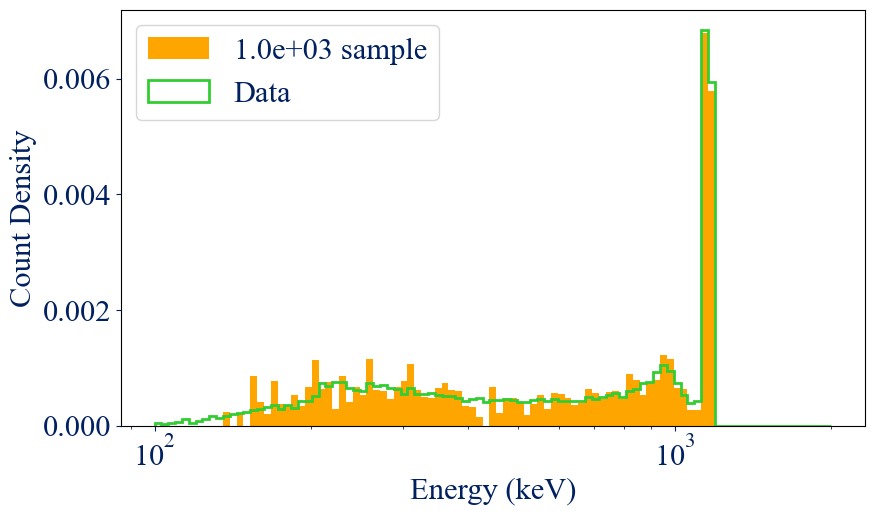

In [7]:
bins = np.logspace(2, 3.3, 100)*u.keV

# plt.xlim([1100, 1200])
plt.hist(energy_samples, bins=bins, density=True, label=f'{num_samples:.1e} sample')
plt.hist(data['Energies'], bins=bins.value, density=True, lw=2, histtype='step', label='Data')
plt.xlabel('Energy (keV)')
plt.ylabel('Count Density')
plt.xscale('log')
plt.legend()
plt.show()

#### Reduce background data file

In [ ]:
from astropy.io import fits
bg_filepath = DATA_DIR / 'data/backgrounds/unbinned/AlbedoPhotons_44Ti.fits'

# Open original FITS file
with fits.open(bg_filepath) as hdul:
    # Assume the data is in a binary table in the first extension (not primary HDU)
    table_data = hdul[1].data
    header = hdul[1].header
    cols = hdul[1].columns

    # Create a dictionary of reduced arrays
    reduced_columns = {}
    for key in cols.names:
        original_array = table_data[key]
        
        # Example reduction: keep every 10th element
        reduced_columns[key] = original_array[indices]

    # Create new columns for the reduced table
    new_columns = []
    for col in cols:
        new_col = fits.Column(name=col.name, array=reduced_columns[col.name], format=col.format, unit=col.unit)
        new_columns.append(new_col)

    # Create new binary table HDU
    new_hdu = fits.BinTableHDU.from_columns(new_columns, header=header)

    # Write to new FITS file
    new_hdu.writeto(DATA_DIR / 'data/backgrounds/unbinned/AlbedoPhotons_44Ti_2.fits', overwrite=True)

#### Empirical Model Testing

In [ ]:
instrument_broadening = 5.3/2.355       # keV (see individual model fits to figure out "effective" sigma_e required for each model)
doppler_broadening = 1.63               # 3.85 keV (FWHM for 1000 km/s expanding shell) / 2.355
np.sqrt(instrument_broadening**2 + doppler_broadening**2)

2.77881068386552

In [ ]:
s2 = np.sqrt(2)
tiny = 1e-12

def energy_redistribution_expgaussian(Em, Ei, sigma_e, tau_e):    
    # Exponentially modified gaussian energy redistribution kernel: models probability of detecting Em given true energy Ei
    gss = -sigma_e * sigma_e / tau_e
    arg1 = -(Ei + gss/2.0 - Em) / tau_e
    arg2 = (Ei + gss - Em)/max((tiny), (s2 * sigma_e))
    return 1 / (2 * tau_e) * np.exp(arg1) * (erf(arg2) + 1)

In [69]:
def energy_redistribution_expgaussian_with_step(Em, Ei, sigma_e, tau_e, m_slope, Em0_linear, A_tail=0, sigma_t=None):
    # Hardcoding
    if sigma_t is None:
        sigma_t = sigma_e

    gss = -sigma_e * sigma_e / tau_e
    arg1 = -(Ei + gss/2.0 - Em) / tau_e
    arg2 = (Ei + gss - Em)/max((tiny), (s2 * sigma_e))
    tail = A_tail * erfc((Em - Ei) / sigma_t)
    right_triangle = m_slope * np.heaviside(Em - Em0_linear, 1) * np.heaviside(Ei - Em, 1) * (Em - Em0_linear)
    right_triangle_area = 0.5 * m_slope * (Ei - Em0_linear)**2
    return (1 / (2 * tau_e) * np.exp(arg1) * (erf(arg2) + 1) + tail + right_triangle) / (1 + A_tail + right_triangle_area)        # Denominator for normalization

In [26]:
def energy_redistribution_double_expgaussian(Em, Ei, sigma_e, w1, tau_1, tau_2):
    return w1 * energy_redistribution_expgaussian(Em, Ei, sigma_e, tau_1) + \
           (1 - w1) * energy_redistribution_expgaussian(Em, Ei, sigma_e, tau_2)

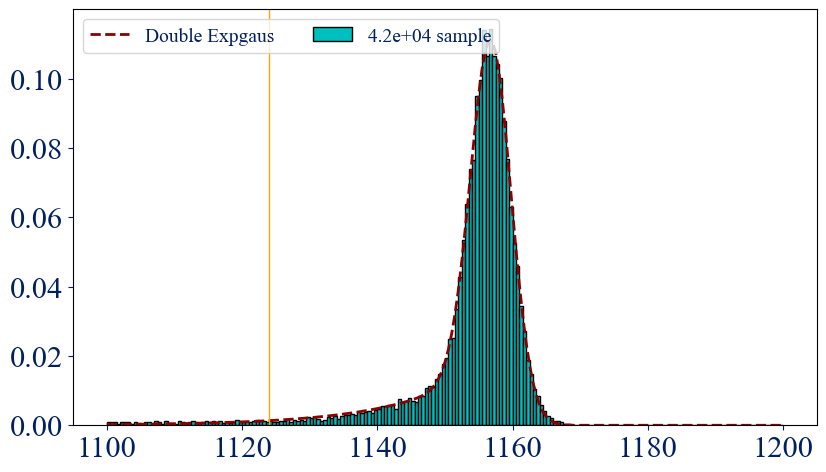

In [ ]:
x1 = np.linspace(1100, 1200, 201)

# plt.plot(x1, energy_redistribution_expgaussian(x1, *popt), c='k', ls='--', lw=2, label='Expgaus')
# plt.plot(x1, energy_redistribution_expgaussian(x1, 1158.91, 2.56, 3.22), c='k', ls='--', lw=2, label='Expgaus')
# plt.plot(x1, energy_redistribution_expgaussian_with_step(x1, *popt), c='k', ls='--', lw=2, label='Linear step')
# plt.plot(x1, energy_redistribution_expgaussian_with_step(x1, 1158.1, 2.88, 1.36, 5.5e-4, 1128), c='k', ls='--', lw=2, label='Linear step')
# plt.plot(x1, gaussian(x1, *popt), c='darkred', ls='--', lw=2, label='Gaussian')
# plt.plot(x1, gaussian(x1, 0.86, 1157, 3.1), c='darkred', ls='--', lw=2, label='Gaussian')
# plt.plot(x1, energy_redistribution_double_expgaussian(x1, *popt), c='darkred', ls='--', lw=2, label='Double Expgaus')
plt.plot(x1, energy_redistribution_double_expgaussian(x1, 1157.47, 2.92, 0.7625, 0.636, 12.5), c='darkred', ls='--', lw=2, label='Double Expgaus')

plt.axvline(1124, lw=1)
# plt.xlim(left=1152)
# plt.ylim(top=0.01)

plt.hist(data['Energies'], bins=np.linspace(1100, 1200, 201), density=True, label=f"{len(data['Energies']):.1e} sample", edgecolor='k', facecolor='c')
plt.legend(ncols=2, fontsize=14, loc='upper left')
plt.show()

In [ ]:
# Gaussian best fit

bins = np.linspace(1100, 1200, 101)
xdata = (bins[1:] + bins[:-1]) / 2
ydata, _ = np.histogram(data['Energies'], bins=bins, density=True)

min_idx = 51
popt, pcov = curve_fit(gaussian, xdata[min_idx:], ydata[min_idx:], 
                       p0 = [0.85, 1157 * np.random.normal(1, 1e-4), np.random.uniform(2.5, 3.5)],
                       bounds = ((0.7, 1156, 2.), (1.1, 1158, 4.0)))

popt

array([8.57587425e-01, 1.15699000e+03, 3.09872645e+00])

In [102]:
# Expgaus best fit

bins = np.linspace(1100, 1200, 101)
xdata = (bins[1:] + bins[:-1]) / 2
ydata, _ = np.histogram(data['Energies'], bins=bins, density=True)

min_idx = 52
popt, pcov = curve_fit(energy_redistribution_expgaussian, xdata[min_idx:], ydata[min_idx:], 
                       p0 = [1157 * np.random.normal(1, 1e-4), np.random.uniform(2.5, 3.0), np.random.uniform(3, 4)],
                       bounds = ((1155, 2.0, 0.5), (1160, 4.0, 10.0)))

popt

array([1159.02102791,    2.43495639,    3.7668057 ])

In [109]:
# Expgaus_with_step best fit

bins = np.linspace(1100, 1200, 101)
xdata = (bins[1:] + bins[:-1]) / 2
ydata, _ = np.histogram(data['Energies'], bins=bins, density=True)

min_idx = 28
popt, pcov = curve_fit(energy_redistribution_expgaussian_with_step, xdata[min_idx:], ydata[min_idx:], 
                       p0 = [1157, np.random.uniform(2.5, 3.0), np.random.uniform(3, 4), 4e-4, 1134],
                       bounds = ((1155, 2.0, 0.5, 1e-4, 1128), (1160, 4.0, 10.0, 1e-3, 1135)))

popt

array([1.15811000e+03, 2.88445530e+00, 1.36201992e+00, 5.49862458e-04,
       1.12800000e+03])

In [200]:
# Double expgaus best fit
# w2 = (1 - w1)

bins = np.linspace(1100, 1200, 101)
xdata = (bins[1:] + bins[:-1]) / 2
ydata, _ = np.histogram(data['Energies'], bins=bins, density=True)

min_idx = 24
popt, pcov = curve_fit(energy_redistribution_double_expgaussian, xdata[min_idx:], ydata[min_idx:], 
                       p0 = [1157, np.random.uniform(2.5, 3.0), 0.5, 5, 10],
                       bounds = ((1156, 2.0, 0.01, 0.5, 0.5), (1158, 4.0, 0.99, 10, 15)))

popt

array([1.15741495e+03, 2.91873596e+00, 7.62562499e-01, 6.36430552e-01,
       1.24999562e+01])

In [ ]:
# If w1 and w2 are separate parameters
popt[2], popt[4], popt[2] + popt[4]

(0.7555576635916846, 0.23580133513358084, 0.9913589987252655)

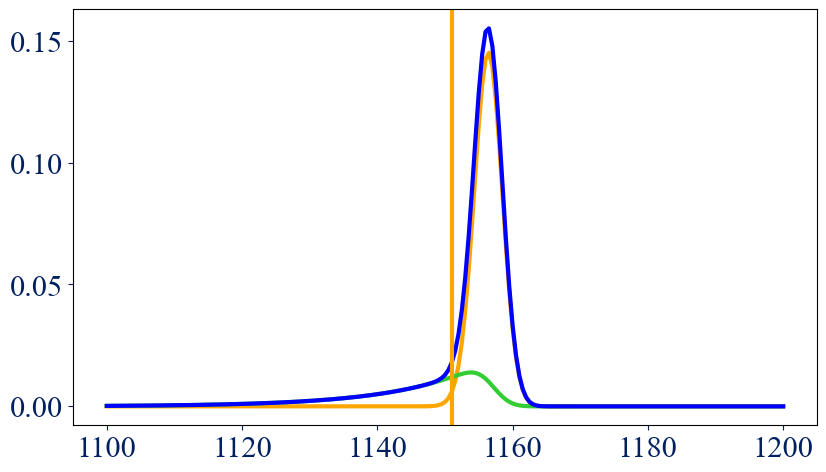

In [259]:
tau1 = 0.636
tau2 = 12.5
w1 = 0.76
w2 = 1 - w1

plt.plot(x1, w1 * energy_redistribution_expgaussian(x1, 1157, 2, tau1))
plt.plot(x1, w2 * energy_redistribution_expgaussian(x1, 1157, 2, tau2))
plt.plot(x1, w1 * energy_redistribution_expgaussian(x1, 1157, 2, tau1) + 
             w2 * energy_redistribution_expgaussian(x1, 1157, 2, tau2))
plt.axvline(1151)

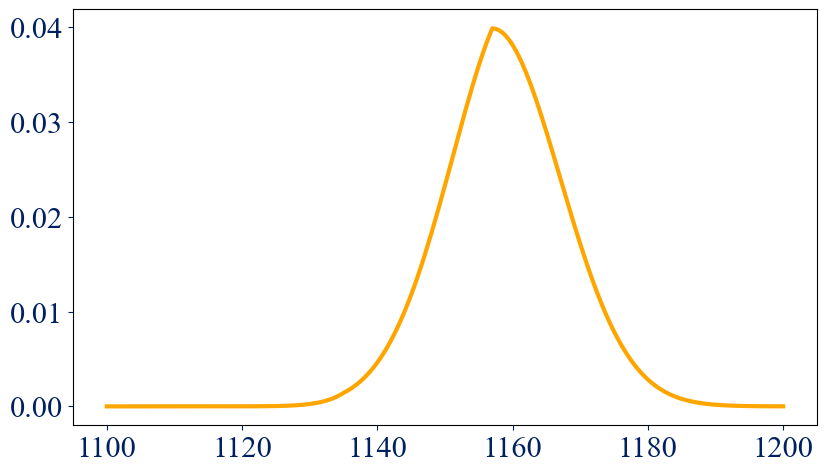

In [ ]:
# Piece-wise exponential tail

tau1 = 17
tau2 = 24
E1 = 1135
E2 = 1157
sigma = 10

plt.plot(x1, np.where(x1 >= E2, gaussian(x1, center=E2, sigma=sigma), 0) + 
             np.where((x1 >= E1) & (x1 < E2), gaussian(x1, center=E2, sigma=sigma) * np.exp((x1 - E2)/tau2), 0) + 
             np.where(x1 < E1, gaussian(x1, center=E2, sigma=sigma) * np.exp((x1 - E2)/tau2) * np.exp((x1 - E1)/tau1), 0)
             )

#### Plots

In [ ]:
Psi_sc = data['Psi local'] * u.rad
Chi_sc = data['Chi local'] * u.rad
# pixels = hp.ang2pix(nside=16, theta=Psi_sc.value, phi=Chi_sc.value, nest=False, lonlat=False)       # theta = polar angle (co-latitude), phi = azimuthal angle (longitude-like)

Psi_gal = data['Psi galactic'] * u.deg
Chi_gal = data['Chi galactic'] * u.deg
# Chi_gal = np.where(Chi_gal > 180 * u.deg, Chi_gal - 360 * u.deg, Chi_gal)

pixels = hp.ang2pix(nside=nside, theta=Chi_gal.value, phi=Psi_gal.value, nest=False, lonlat=True)      # theta = l, phi = b

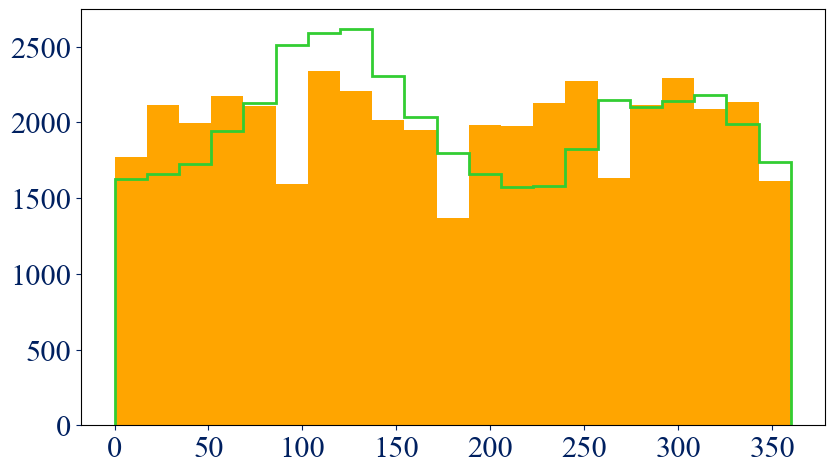

In [6]:
plt.hist(Chi_sc.to(u.deg), bins=21)
plt.hist(Chi_gal, bins=21, histtype = 'step', lw=2)     # l
plt.show()

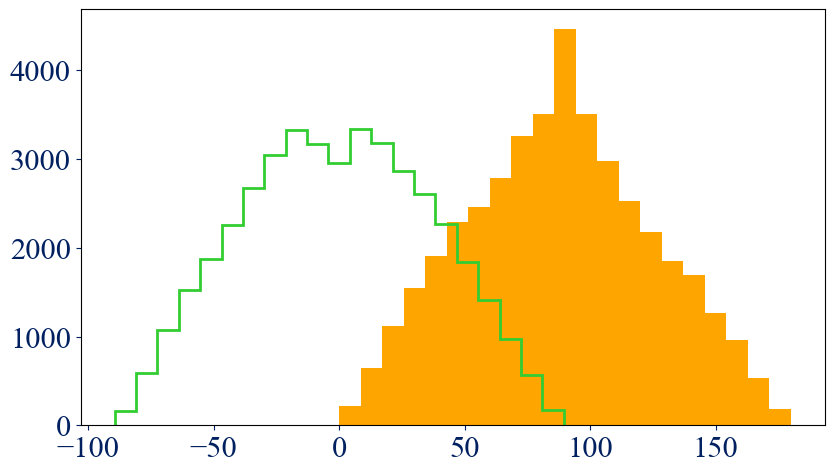

In [7]:
plt.hist(Psi_sc.to(u.deg), bins=21)
plt.hist(Psi_gal, bins=21, histtype = 'step', lw=2)     # b
plt.show()

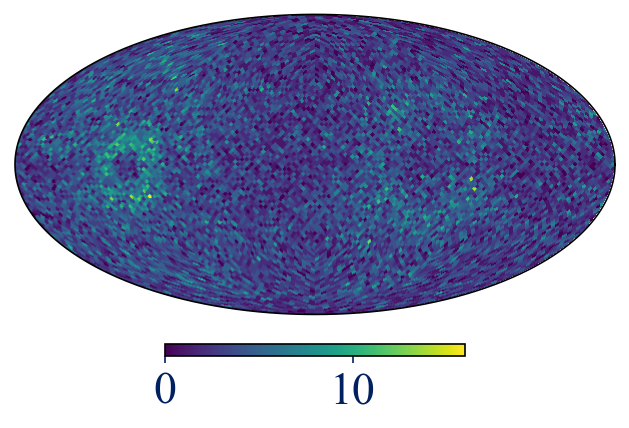

In [8]:
# Define the grid and initialize
m = HealpixMap(nside = nside, scheme = 'RING', dtype = int)

for p in pixels:
    m[p] += 1

m.plot()
plt.show()

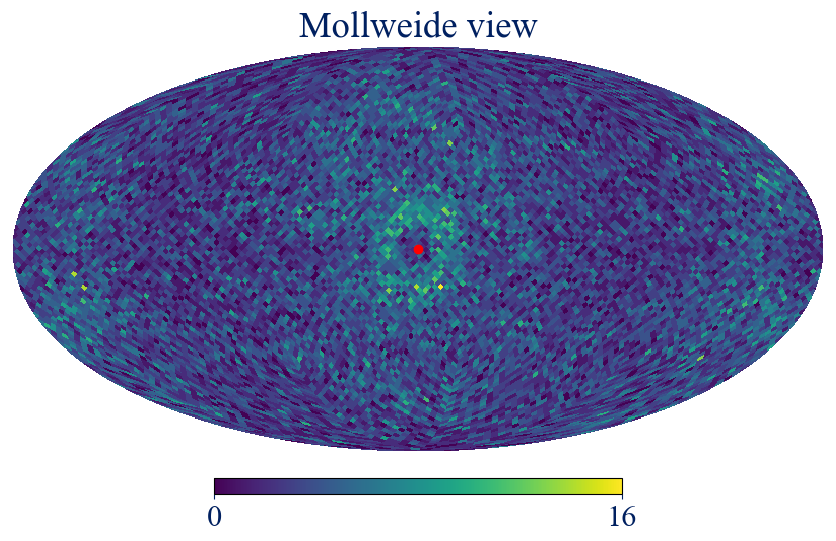

In [9]:
hp.mollview(m._data, rot=[l, b])
hp.projplot(l, b, c='r', marker='o', lonlat=True)
plt.show()

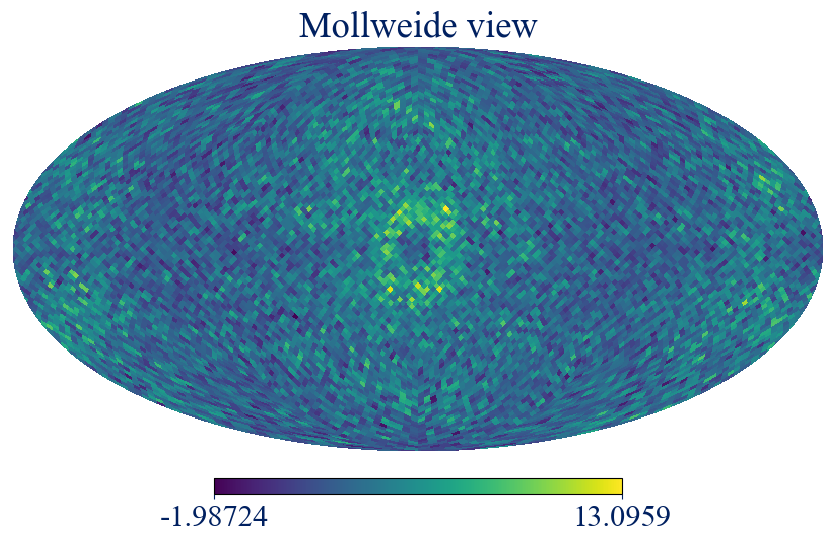

In [10]:
# Rotate the grid
rot_custom = hp.Rotator(rot=[l, b], inv=False)
data_rotated_alms = rot_custom.rotate_map_alms(m._data)

hp.mollview(data_rotated_alms)
plt.show()

#### 

In [8]:
rot_custom = hp.Rotator(rot=[l, b-90], inv=False)       # -90 ensures that Cas A is situated at hp pixel = 0

ang_rot = rot_custom(chi_gal_samples.value, psi_gal_samples.value, lonlat=True)
Psi_sc_onaxis = ang_rot[1] * u.deg      # b
Chi_sc_onaxis = ang_rot[0] * u.deg      # l

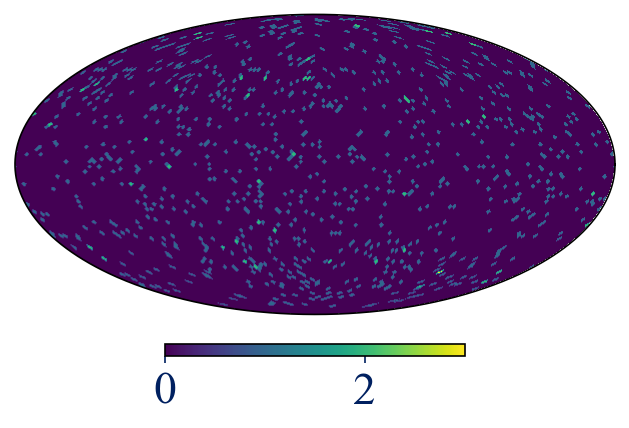

In [9]:
# Define the grid and initialize
pixels_rot = hp.ang2pix(nside=nside, theta=ang_rot[0], phi=ang_rot[1], nest=False, lonlat=True)     # l, b
m_rot = HealpixMap(nside = nside, scheme = 'RING', dtype = int)

for p in pixels_rot:
    m_rot[p] += 1

m_rot.plot()
plt.show()

In [10]:
bg_ang_rot = rot_custom(bg_dict['Chi galactic'], bg_dict['Psi galactic'], lonlat=True)
background_data = np.array([bg_dict['Energies'], bg_dict['Phi'], bg_ang_rot[1], bg_ang_rot[0]])

background_kde = gaussian_kde(background_data[[0,3],:])

### Interpolation

In [11]:
def get_all_interp_weights(dr, target: dict):
    indices = []
    weights = []

    for label in dr.axes.labels:

        if label == 'Phi':
            key = label

        elif label == 'PsiChi':
            key = label

        else:
            raise ValueError(f'Label: {label} is not supported')
        
        axis = dr.axes[label]

        axis_type = str(type(axis)).split('.')[-1].strip("'>")      # XXX: Could probably be simplified using `isinstance()`

        # Axis Type
        if axis_type in ['Axis', 'HealpixAxis']:

            if key == 'Phi':
                idx, w = axis.interp_weights(target[key])

            elif key == 'PsiChi':
                idx, w = axis.interp_weights(SkyCoord(target['Chi_sc'], target['Psi_sc'], frame=SpacecraftFrame()))     # l, b

        else:
            raise ValueError(f'Axis type: {axis_type} is not supported')
        
        indices.append(idx)
        weights.append(w)
    
    return (indices, weights)

def get_interp_response(dr, target: dict):
    """
    Currently only supports nonlinear spectral responses (
    and for a particular parametrization)
    TODO: In the future, this will also support nonlinear / 
    piecewise-linear directional responses.
    """

    indices, weights = get_all_interp_weights(dr, target)
    perm_indices = list(itertools.product(*indices))
    perm_weights = list(itertools.product(*weights))
    
    interpolated_response_value = 0
    for idx, w in zip(perm_indices, perm_weights):
        interpolated_response_value += np.prod(w) * dr.contents[idx]
    
    return interpolated_response_value

hist = dr.project('Phi', 'PsiChi')
dr2 = DetectorResponse(coord = dr.coord, edges=hist.axes, contents=hist.contents, unit=dr.unit)

#### Plots

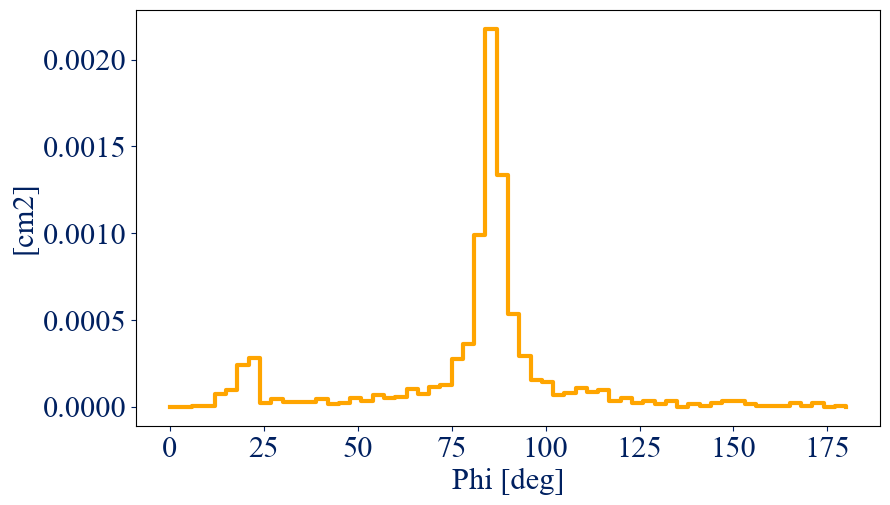

In [16]:
dr2.slice[:,1500].project('Phi').plot()
plt.show()

In [17]:
hp.pix2ang(nside=16, ipix=1500, lonlat=True)

(337.49999999999994, 2.388015463268772)

In [18]:
Phi0 = 45 * u.deg
Psi_gal0 = 2.388 * u.deg     # b
Chi_gal0 = 337.5 * u.deg       # l
target = {'Phi': Phi0, 'Psi_sc': Psi_gal0, 'Chi_sc': Chi_gal0}

get_interp_response(dr2, target)


WARNING UserWarning: len(target) != len(dr.axes)



<Quantity 1.81444463e-05 cm2>


WARNING UserWarning: len(target) != len(dr.axes)



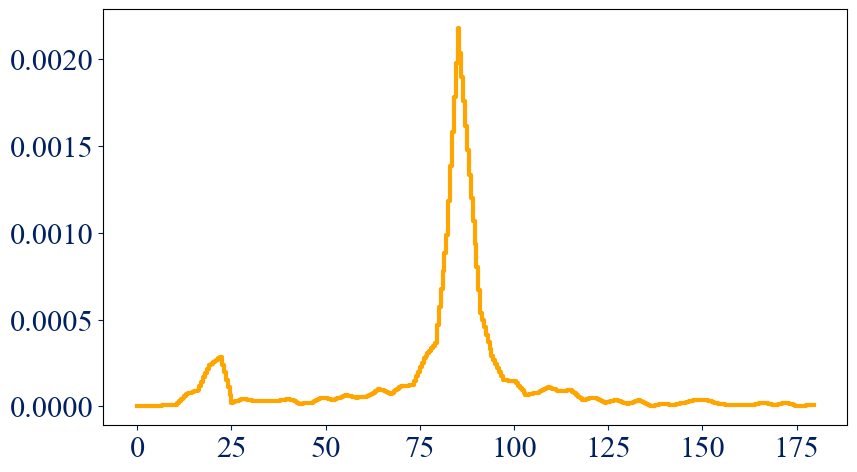

In [19]:
Phi = np.arange(180, step=0.5) * u.deg
rsp = []
for p in Phi:
    target = {'Phi': p, 'Psi_sc': Psi_gal0, 'Chi_sc': Chi_gal0}
    rsp.append(get_interp_response(dr2, target))
plt.step(Phi, Quantity(rsp))
plt.show()

### Spectrum

In [15]:
class COSILikeNew(PluginPrototype):

    def __init__(self, name, dr, exposure_time, energy_samples, 
                 phi_samples, psi_samples, chi_samples, 
                 spectrum_unit, nuisance_param, 
                 Eiedges = np.array([1154, 1160]) * u.keV, 
                 sigma_e = 5.3/2.355 * u.keV, 
                 tau_e = 1 * u.keV, 
                 energy_redistribution_kernel = None,
                 background_kde = background_kde):
        
        super().__init__(name, nuisance_param)  # Initialize plugin base class with name and nuisance parameters

        # Define constants
        self._s2 = np.sqrt(2)
        self._s2pi = np.sqrt(2 * np.pi)
        self._tiny = 1e-12

        # Raw detector response and observation metadata
        self._dr = dr
        self._exposure_time = exposure_time.to('s')

        # Observed event-level data
        self._energy_samples = energy_samples              # Measured energies
        self._phi_samples = phi_samples                    # Scattering angles
        self._psi_samples = psi_samples                    
        self._chi_samples = chi_samples                    

        # Spectral integration boundaries and resolution
        self._Eiedges = Eiedges                            # True energy range to integrate over. For time being, assumed to be the measured energy range too.
        self._delta_Ei = Eiedges[-1] - Eiedges[0]          # Width of true energy integration window
        self._delta_Em = Eiedges[-1] - Eiedges[0]          # Width of measured energy range (used for convolution)

        self._spectrum_unit = spectrum_unit                # Unit of spectral flux (e.g., ph/cm²/s/keV)
        self._n_events = len(energy_samples)               # Total number of observed events
        self._sigma_e = sigma_e                            # Gaussian energy resolution
        self._tau_e = tau_e                             # Expgaussian tailing
        self._tau_1 = 0.636 * u.keV                     # Double expgaussian tailing. Hardcoded based on empirical modeling of 1157 keV line. May change for other line energies.
        self._tau_2 = 12.5 * u.keV 
        self._w1 = 0.7626                               # Relative weights of double expgaussian. May change for other line energies. 

        self._effective_area = np.sum(self._dr.contents)           # Effective area of the detector hardcoded for line fitting
        self._energy_redistribution_kernel = energy_redistribution_kernel                # If None, then we are effectively modeling a detector with infinite energy resolution
        self._background_kde = background_kde

    def gaus_kernel(self, Ei, Em, sigma_e):
        # Gaussian energy dispersion kernel
        # Probability of detecting Em given true energy Ei
        return (1 / (self._s2pi * sigma_e)) * np.exp(-((Em - Ei)**2) / (2 * sigma_e**2))

    def integrated_gaus_kernel(self, Ei, Eiedges, sigma_e):
        # Analytical integration of the gaussian kernel from E_min to E_max
        # Probability that an event with true energy Ei lands within measured range [E_min, E_max]
        return 0.5 * (erfc((Eiedges[0] - Ei) / (self._s2 * sigma_e)) -
                erfc((Eiedges[-1] - Ei) / (self._s2 * sigma_e)))
    
    def expgaus_kernel(self, Ei, Em, sigma_e, tau_e):    
        # Exponentially modified gaussian energy dispersion kernel
        gss = -sigma_e * sigma_e / tau_e
        arg1 = -(Ei + gss/2.0 - Em) / tau_e
        arg2 = (Ei + gss - Em)/max((self._tiny * sigma_e.unit), (self._s2 * sigma_e))
        return 1 / (2 * tau_e) * np.exp(arg1) * (erf(arg2) + 1)
    
    def integrated_expgaus_kernel(self, Ei, Eiedges, sigma_e, tau_e):
        # Numerically integrate the expgaussian kernel from E_min to E_max
        redistribution_kernel = lambda Em: self.expgaus_kernel(Ei, Em * u.keV, sigma_e, tau_e) * u.keV      # This is here instead of the next line as the integral will fail otherwise

        result = integrate.quad(redistribution_kernel, Eiedges[0].value, Eiedges[-1].value)[0]
        return result
    
    def double_expgaus_kernel(self, Ei, Em, sigma_e, w1, tau_1, tau_2):
        return w1 * self.expgaus_kernel(Ei, Em, sigma_e, tau_1) + \
               (1 - w1) * self.expgaus_kernel(Ei, Em, sigma_e, tau_2)
    
    def integrated_double_expgaus_kernel(self, Ei, Eiedges, sigma_e, w1, tau_1, tau_2):
        # Numerically integrate the double expgaussian kernel from E_min to E_max
        redistribution_kernel = lambda Em: self.double_expgaus_kernel(Ei, Em * u.keV, sigma_e, 
                                                                      w1, tau_1, tau_2) * u.keV

        result = integrate.quad(redistribution_kernel, Eiedges[0].value, Eiedges[-1].value, 
                                epsabs=1e-6, epsrel=1e-6)[0]
        return result

    def set_model(self, likelihood_model):
        # Set the spectral model (typically ThreeML source model)
        self._likelihood_model = likelihood_model

    def _compute_signal_density(self, Em, Phi, Psi, Chi, Ei_min, Ei_max, redistribution_kernel, spectrum):
        
        if redistribution_kernel is None:
            dispersed_spectrum = spectrum
        else:
            dispersed_spectrum = lambda Ei: redistribution_kernel(Ei, Em)

        integrated_flux = integrate.quad(dispersed_spectrum, Ei_min, Ei_max)[0] * self._spectrum_unit * u.keV
        
        event_angles = {'Phi': Phi, 'Psi_sc': Psi, 'Chi_sc': Chi}
        signal_density = get_interp_response(self._dr, event_angles) * integrated_flux * self._exposure_time

        return signal_density

    def _compute_predicted_a(self):
        Eiedges = self._Eiedges
        delta_Em = self._delta_Em
        spectrum = self._likelihood_model.source.spectrum.main.shape
        kernel_name = self._energy_redistribution_kernel
        background_norm = bgcounts #self._nuisance_parameters['testing']

        # Mask samples outside the region that will predominantly 
        # contribute to line emission. Eiedges is chosen by user. 
        mask = (self._energy_samples >= Eiedges[0]) & (self._energy_samples <= Eiedges[-1])
        energy_samples = self._energy_samples[mask]
        phi_samples = self._phi_samples[mask]
        psi_samples = self._psi_samples[mask]
        chi_samples = self._chi_samples[mask]

        # Kernal dictionary
        available_kernels = {
                    'gaus': lambda Ei, Em: spectrum(Ei) * self.gaus_kernel(Ei * u.keV, Em, self._sigma_e) * delta_Em,
                    'expgaus': lambda Ei, Em: spectrum(Ei) * self.expgaus_kernel(Ei * u.keV, Em, self._sigma_e, 
                                                                                 self._tau_e) * delta_Em,
                    'doubleexpgaus': lambda Ei, Em: spectrum(Ei) * self.double_expgaus_kernel(Ei * u.keV, Em, self._sigma_e, 
                                                                                 self._w1, self._tau_1, self._tau_2) * delta_Em
                }
        
        redistribution_kernel = available_kernels.get(kernel_name, None)

        # Integration bounds
        Ei_min = Eiedges[0].value
        Ei_max = Eiedges[-1].value

        args = zip(energy_samples, phi_samples, psi_samples, chi_samples)
        compute_func = lambda Em, Phi, Psi, Chi: self._compute_signal_density(Em, Phi, Psi, Chi, Ei_min=Ei_min, Ei_max=Ei_max,
                                                                              redistribution_kernel=redistribution_kernel, spectrum=spectrum)
        
        # signal_densities = []
        # for Em, Phi, Psi, Chi in args:
        #     signal_density = compute_func(Em, Phi, Psi, Chi)
        #     signal_densities.append(signal_density)
        with mp.Pool(processes = 10) as pool:
            signal_densities = Quantity(pool.starmap(compute_func, args))                             # Each entry is the predicted density for one observed event

        background_densities = self._background_kde([energy_samples.value, chi_samples.value])        # Currently using the two KDE variables with maximal discriminating power
        eventwise_expectation_densities = Quantity(signal_densities) + background_densities * background_norm

        return eventwise_expectation_densities


    def _compute_predicted_c(self):
        # Compute total expected number of counts over full observation and ROI
        Eiedges = self._Eiedges
        spectrum = self._likelihood_model.source.spectrum.main.shape

        # Kernel dictionary
        available_kernels = {
            'gaus': lambda Ei: spectrum(Ei) * self.integrated_gaus_kernel(Ei * u.keV, Eiedges, self._sigma_e),
            'expgaus': lambda Ei: spectrum(Ei) * self.integrated_expgaus_kernel(Ei * u.keV, Eiedges, self._sigma_e, self._tau_e),
            'doubleexpgaus': lambda Ei: spectrum(Ei) * self.integrated_double_expgaus_kernel(
                Ei * u.keV, Eiedges, self._sigma_e, self._w1, self._tau_1, self._tau_2)
        }

        # Select folded_spectrum function
        folded_spectrum = available_kernels.get(self._energy_redistribution_kernel, spectrum)

        integrated_flux_over_roi = integrate.quad(folded_spectrum, Eiedges[0].value, Eiedges[-1].value)[0] * \
                                   self._spectrum_unit * u.keV

        signal_counts = self._effective_area * integrated_flux_over_roi * self._exposure_time
        background_counts = bgcounts #self._nuisance_parameters['testing']
        total_expected_counts = signal_counts + background_counts
        return total_expected_counts

    def get_log_like(self):
        # Final log-likelihood: Poisson likelihood from eventwise 
        # expectation density and total expected counts
        eventwise_expectation_density = self._compute_predicted_a()
        total_expected_counts = self._compute_predicted_c()
        log_like = -total_expected_counts + np.sum(np.log(eventwise_expectation_density + self._tiny))
        return log_like

    def inner_fit(self):
        # Wrapper method for fit logic
        return self.get_log_like()

    def get_number_of_data_points(self):
        return self._n_events

    def get_number_of_model_parameters(self):
        return self._likelihood_model.get_number_of_free_parameters()
    
    def display_model(self, Ei = None, norm = 1):
        # Does not fold with phi and psichi response
        # Incident energy grid (Ei): where photons originate
        if Ei is None:
            Ei = np.linspace(self._Eiedges[0], self._Eiedges[-1], 501)  # keV

        # Measured energy bins (Em): what the detector sees
        Em_bins = np.linspace(self._Eiedges[0], self._Eiedges[-1], 101)  # Measured energy bin edges
        Em_centers = 0.5 * (Em_bins[1:] + Em_bins[:-1])

        # Build redistribution matrix R[Em, Ei]
        if self._energy_redistribution_kernel == 'gaus':
            R = np.array([
                self.gaus_kernel(Ei, Em, self._sigma_e)
                for Em in Em_centers
            ])
        elif self._energy_redistribution_kernel == 'expgaus':
            R = np.array([
                self.expgaus_kernel(Ei, Em, self._sigma_e, self._tau_e)
                for Em in Em_centers
            ])
        elif self._energy_redistribution_kernel == 'doubleexpgaus':
            R = np.array([
                self.double_expgaus_kernel(Ei, Em, self._sigma_e, self._w1, self._tau_1, self._tau_2)
                for Em in Em_centers
            ])

        # Convolve model spectrum with redistribution matrix
        spectrum = self._likelihood_model.source.spectrum.main.shape
        dEi = Ei[1] - Ei[0]  # Energy bin width
        folded_counts = R @ spectrum(Ei - 0.5 * Ei.unit) * dEi  # Expected counts per measured bin

        plt.figure(figsize=(8, 5))
        plt.plot(Em_centers, folded_counts * self._effective_area * self._exposure_time, label="FF", color='darkorange')
        plt.xlabel("Measured Energy (keV)")
        plt.ylabel("Expected Counts")
        plt.title("Forward Folded Model Spectrum")
        # plt.axvline(1149.35)
        counts, _ = np.histogram(self._energy_samples, Em_bins)
        plt.stairs(norm * counts, Em_bins.value, edgecolor='b', lw=2, label='Data')

        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        return plt

#### Plots

In [ ]:
COSILikeNew.integrated_energy_redistribution_gaussian(cosi, 1157 * u.keV, np.array([1154, 1160])*u.keV, 2 * u.keV)

<Quantity 0.8663856>

In [ ]:
COSILikeNew.integrated_energy_redistribution_expgaussian(cosi, 1157 * u.keV, np.array([1154, 1160])*u.keV, 2 * u.keV, 1 * u.keV)

0.7874061966541395

In [ ]:
COSILikeNew.integrated_energy_redistribution_double_expgaussian(cosi, 1157 * u.keV, np.array([1130, 1160])*u.keV, 2.41 * u.keV, cosi._w1, cosi._tau_1, cosi._tau_2)

0.9155100739401539

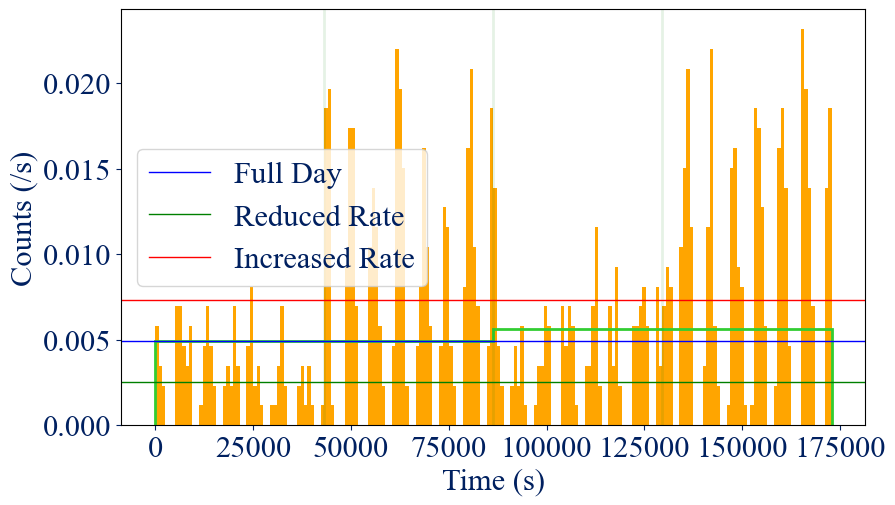

In [42]:
t0 = data['TimeTags'].min()
numdays = 2
bins = np.linspace(0, 86400*numdays, 100 * numdays + 1)
counts, _ = np.histogram(data['TimeTags'] - t0, bins=bins)
plt.stairs(counts / np.diff(bins), bins, fill=True)

counts, bins = np.histogram(data['TimeTags'] - t0, bins=np.arange(0, 86400*numdays+1, 86400))
plt.stairs(counts / np.diff(bins), bins, lw=2)

for i in range(1, numdays*2):
    plt.axvline(i * 86400/2, c='g', lw=2, alpha=0.1)

ff = 1#15/5

cond = (data['TimeTags'] < t0+86400)
plt.axhline(len(data['TimeTags'][cond]) / 86400 * ff, label='Full Day', lw=1, c='b')
cond = (data['TimeTags'] < t0+86400/2)
plt.axhline(len(data['TimeTags'][cond]) / (86400/2) * ff, label='Reduced Rate', lw=1, c='g')
cond = (data['TimeTags'] < t0 + 86400) & (data['TimeTags'] > t0 + 86400/2)
plt.axhline(len(data['TimeTags'][cond]) / (86400/2) * ff, label='Increased Rate', lw=1, c='r')

plt.xlabel('Time (s)')
plt.ylabel('Counts (/s)')
plt.legend()
plt.show()

74.0 34.0
139.0 176.0


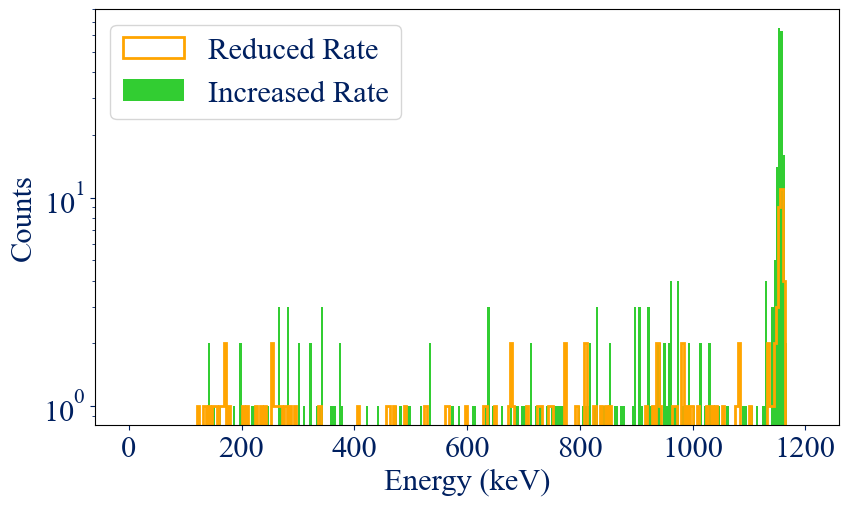

In [23]:
bins = np.linspace(0, 1200, 301)

cond = (data['TimeTags'] < t0 + 86400/2)
counts, _, _ = plt.hist(data['Energies'][cond], bins=bins, histtype='step', lw=2, label='Reduced Rate')
print(np.sum(counts[:275]), np.sum(counts[275:]))
cond = (data['TimeTags'] < t0 + 86400) & (data['TimeTags'] > t0 + 86400/2)
counts, _, _ = plt.hist(data['Energies'][cond], bins=bins, label='Increased Rate')
print(np.sum(counts[:275]), np.sum(counts[275:]))
plt.xlabel('Energy (keV)')
plt.ylabel('Counts')
plt.yscale('log')
plt.legend()
plt.show()

####

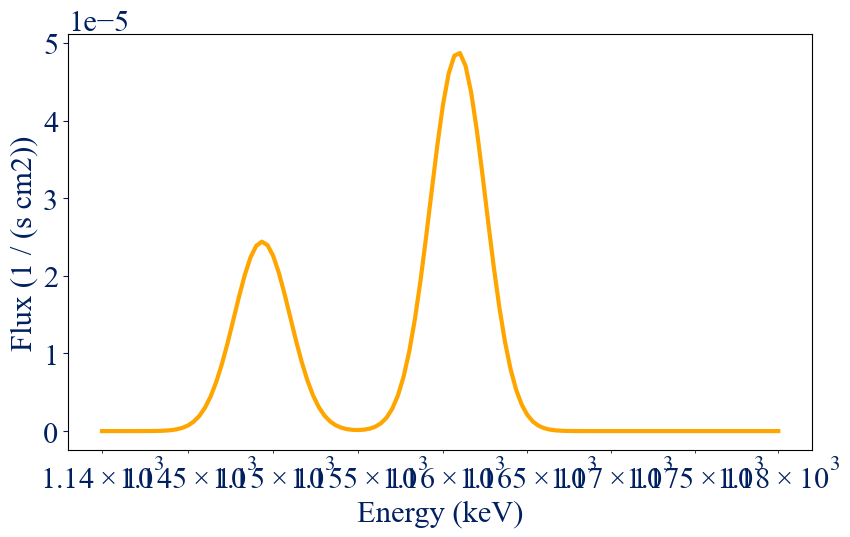

In [44]:
def spectrum_reset(spec):
    if name == 'CasAsymmetric':
        F = 3e-4 / u.cm / u.cm / u.s
        mu = 1157 * u.keV
        sigma = 3.85/2.355 * u.keV

        spec.F.value = F.value
        spec.F.min_value = F.value / 1e3
        spec.F.max_value = F.value * 1e3
        spec.F.unit = F.unit
        spec.mu.value = mu.value 
        spec.mu.min_value = mu.value - 10
        spec.mu.max_value = mu.value + 10
        spec.mu.unit = mu.unit
        spec.sigma.value = sigma.value
        spec.sigma.min_value = sigma.value - 5
        spec.sigma.max_value = sigma.value + 5
        spec.sigma.unit = sigma.unit

    else:
        # Input .source values
        F1 = 1e-4 / u.cm / u.cm / u.s
        mu1 = {'CasAfullyresolved': 1149.35, 
               'CasApartiallyresolved': 1152.41, 
               'CasAunresolved': 1153.17}
        mu1 = mu1[name] * u.keV
        sigma1 = 3.85 * u.keV / 2.355
 
        F2 = 2 * F1
        mu2 = {'CasAfullyresolved': 1160.89, 
               'CasApartiallyresolved': 1159.34, 
               'CasAunresolved': 1158.95}
        mu2 = mu2[name] * u.keV
        sigma2 = sigma1
 
        # Define the first Gaussian
        spec.F_1.value = F1.value
        spec.F_1.min_value = F1.value / 1e2
        spec.F_1.max_value = F1.value * 1e2
        spec.F_1.unit = F1.unit
        spec.mu_1.value = mu1.value
        spec.mu_1.min_value = mu1.value - 10
        spec.mu_1.max_value = mu1.value + 10
        spec.mu_1.unit = mu1.unit
        spec.sigma_1.value = sigma1.value
        spec.sigma_1.min_value = sigma1.value - 5
        spec.sigma_1.max_value = sigma1.value + 5
        spec.sigma_1.unit = sigma1.unit
 
        # Define the second Gaussian
        spec.F_2.value = F2.value
        spec.F_2.min_value = F2.value / 1e2
        spec.F_2.max_value = F2.value * 1e2
        spec.F_2.unit = F2.unit
        spec.mu_2.value = mu2.value
        spec.mu_2.min_value = mu2.value - 10
        spec.mu_2.max_value = mu2.value + 10
        spec.mu_2.unit = mu2.unit
        spec.sigma_2.value = sigma2.value
        spec.sigma_2.min_value = sigma2.value - 5
        spec.sigma_2.max_value = sigma2.value + 5
        spec.sigma_2.unit = sigma2.unit

    return spec

if name == 'CasAsymmetric':
    spectrum = Gaussian()
    spectrum = spectrum_reset(spectrum)
    spectrum_unit = spectrum.F.unit / spectrum.sigma.unit 

    spectrum.F.free = False
    spectrum.mu.free = False
    spectrum.sigma.free = False

else:
    # Create the compound model
    gaussian1 = Gaussian()
    gaussian2 = Gaussian()
    spectrum = gaussian1 + gaussian2
    spectrum = spectrum_reset(spectrum)
    spectrum_unit = spectrum.F_1.unit / spectrum.sigma_1.unit 
    
    spectrum.F_1.free = False
    spectrum.mu_1.free = False
    spectrum.sigma_1.free = False
    spectrum.F_2.free = False
    spectrum.mu_2.free = False
    spectrum.sigma_2.free = False
    

# Generate some data for plotting
xdata = np.linspace(1140, 1180, 121) * u.keV
ydata = spectrum(xdata.value) * spectrum_unit

# Plot the compound model
plt.plot(xdata.value, ydata)
plt.xlabel(f'Energy ({xdata.unit})')
plt.ylabel(f'Flux ({spectrum_unit * u.keV})')
# plt.ylim([0, 1e-5])
plt.xscale('log')
plt.show()

In [45]:
exposure_time = 92.34 * u.d * (num_samples / len(data['Energies'])) * 0.35              # By testing based on simulated counts, 0.35 is a good value (see notes 21.8.25)
print(len(np.where((energy_samples.value > 1130) & (energy_samples.value < 1200))[0]), len(np.where((data['Energies'] > 1130) & (data['Energies'] < 1200))[0]), len(data['Energies']))

441 18745 42350


In [46]:
cosi = COSILikeNew('cosi',                                                     # COSI 3ML plugin
                 dr = dr2,                                                     # detector response (phi and psichi coordinates only)
                 exposure_time = exposure_time,
                 energy_samples = energy_samples,
                 phi_samples = phi_samples,
                 psi_samples = Psi_sc_onaxis,
                 chi_samples = Chi_sc_onaxis, 
                 spectrum_unit = spectrum_unit,
                 Eiedges = np.array([1130, 1200]) * u.keV,
                 sigma_e = 2.41 * u.keV, 
                 nuisance_param = {},                       # background parameter 
                 energy_redistribution_kernel = 'doubleexpgaus'
)   

source = PointSource('source', 
                     l = target_coord.l.value,
                     b = target_coord.b.value,
                     spectral_shape = spectrum)
model = Model(source)
cosi.set_model(model)

In [47]:
cosi._compute_predicted_c()

<Quantity 443.07981343>

In [20]:
aj = cosi._compute_predicted_a()

#### Forward Folding Setup

In [ ]:
cosi._energy_redistribution_kernel = 'gaussian'
cosi._compute_predicted_c()

<Quantity 330.38933621>

In [ ]:
cosi._energy_redistribution_kernel = 'doubleexpgaus'
cosi._compute_predicted_c()

<Quantity 321.09479979>

In [ ]:
cosi._energy_redistribution_kernel = None
cosi._compute_predicted_c()

<Quantity 330.38933621>

In [ ]:
cosi._energy_redistribution_kernel = 'doubleexpgaus'
cosi._Eiedges = np.array([1100, 1200]) * u.keV
cosi._compute_predicted_c()

<Quantity 329.54596105>

In [ ]:
len(np.where((energy_samples.value > 1100) & (energy_samples.value < 1200))[0])

480

<module 'matplotlib.pyplot' from '/Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/matplotlib/pyplot.py'>

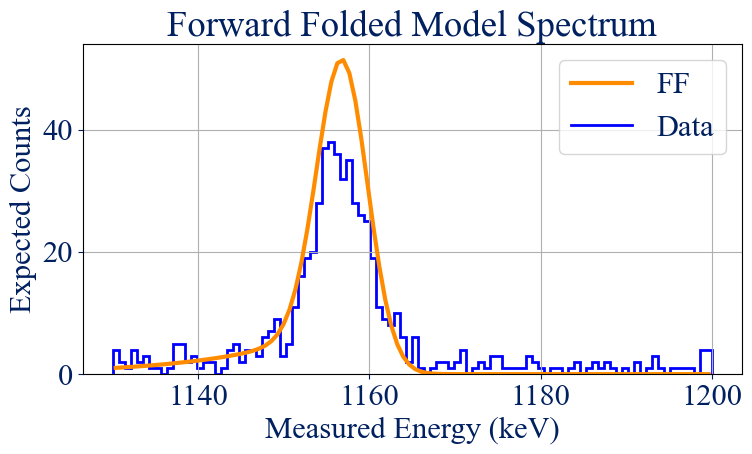

In [55]:
cosi._energy_redistribution_kernel = 'doubleexpgaus'
cosi.display_model()

In [13]:
# Incident energy grid (Ei): where photons originate
Ei = np.linspace(1100, 1200, 501) * u.keV  # keV

# Measured energy bins (Em): what the detector sees
Em_bins = np.linspace(1100, 1200, 101) * u.keV  # Measured energy bin edges
Em_centers = 0.5 * (Em_bins[1:] + Em_bins[:-1])

In [14]:
# Parameters for redistribution
sigma_e = 2.41 * u.keV
w1 = 0.7626
tau_1 = 0.636 * u.keV
tau_2 = 12.5 * u.keV

# Build redistribution matrix R[Em, Ei]
R = np.array([
    cosi.energy_redistribution_double_expgaussian(Ei, Em, sigma_e, w1, tau_1, tau_2)
    for Em in Em_centers
])

In [35]:
# Convolve model spectrum with redistribution matrix
dEi = Ei[1] - Ei[0]  # Energy bin width
folded_counts = R @ spectrum(Ei - 0.5 * Ei.unit) * dEi  # Expected counts per measured bin

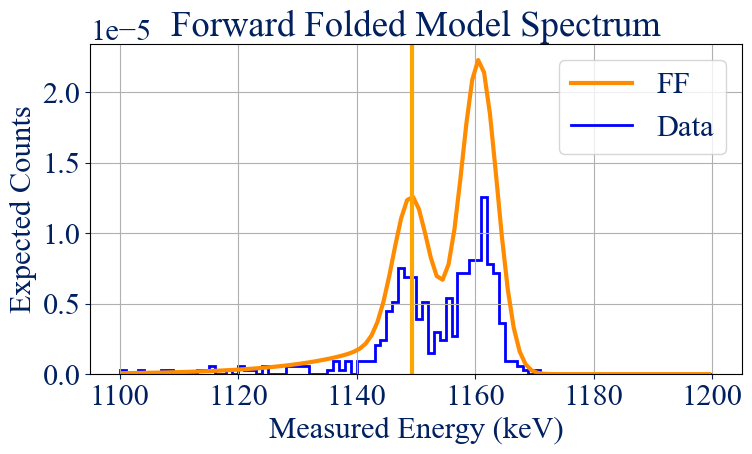

In [42]:
plt.figure(figsize=(8, 5))
plt.plot(Em_centers, folded_counts, label="FF", color='darkorange')
plt.xlabel("Measured Energy (keV)")
plt.ylabel("Expected Counts")
plt.title("Forward Folded Model Spectrum")
plt.axvline(1149.35)
counts, bins = np.histogram(cosi._energy_samples / u.keV, np.linspace(1100, 1200, 101))
plt.stairs(3e-7 * counts, bins, edgecolor='b', lw=2, label='Data')

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#### Likelihood Fitting

In [48]:
plugins = DataList(cosi) # If we had multiple instruments, we would do e.g. DataList(cosi, lat, hawc, ...)

like = JointLikelihood(model, plugins, verbose = False)

like.fit()

13:09:24 INFO      set the minimizer to minuit                                             ]8;id=997542;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=531891;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/classicMLE/joint_likelihood.py#1045\1045]8;;\

         WARNING   There is no free parameter in the current model                          ]8;id=207697;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=67072;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/classicMLE/joint_likelihood.py#246\246]8;;\

13:10:12 WARNING   The current value of the parameter F_1 (1.0) was above the new maximum 0.01.    ]8;id=48368;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=324383;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#794\794]8;;\

         WARNING   The current value of the parameter mu_1 (0.0) was below the new minimum         ]8;id=152287;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=592531;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#720\720]8;;\
                  1139.35.                                                                                         

         WARNING   The current value of the parameter F_2 (1.0) was above the new maximum 0.02.    ]8;id=131934;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=2167;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#794\794]8;;\

         WARNING   The current value of the parameter mu_2 (0.0) was below the new minimum         ]8;id=999518;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=941509;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#720\720]8;;\
                  1150.89.                                                                                         

Best fit values:

13:10:12 WARNING   the positive uncertainty is not finite                               ]8;id=451674;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/io/uncertainty_formatter.py\uncertainty_formatter.py]8;;\:]8;id=710939;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/io/uncertainty_formatter.py#95\95]8;;\

         WARNING   the negative uncertainty is not finite                              ]8;id=244955;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/io/uncertainty_formatter.py\uncertainty_formatter.py]8;;\:]8;id=152573;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/io/uncertainty_formatter.py#101\101]8;;\

ValueError: Cannot set a DataFrame with multiple columns to the single column result

In [36]:
results = like.results

print(results.display())

parameters = {par.name:results.get_variates(par.path)
              for par in results.optimized_model["source"].parameters.values()
              if par.free}

results_err = results.propagate(results.optimized_model["source"].spectrum.main.shape.evaluate_at, **parameters)

print(results.optimized_model["source"])

Best fit values:

,result,unit
parameter,,
source.spectrum.main.composite.mu_1,(1.1506 +/- 0.0004) x 10^3,keV
source.spectrum.main.composite.mu_2,(1.16166 +/- 0.00022) x 10^3,keV


Correlation matrix:

1.00,0.16
0.16,1.00


Values of -log(likelihood) at the minimum:

...

         WARNING   The current value of the parameter F_1 (1.0) was above the new maximum 0.01.    ]8;id=772351;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=653291;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#794\794]8;;\

         WARNING   The current value of the parameter mu_1 (0.0) was below the new minimum         ]8;id=839251;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=823947;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#720\720]8;;\
                  1139.35.                                                                                         

         WARNING   The current value of the parameter F_2 (1.0) was above the new maximum 0.02.    ]8;id=258093;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=422504;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#794\794]8;;\

         WARNING   The current value of the parameter mu_2 (0.0) was below the new minimum         ]8;id=137606;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=440777;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#720\720]8;;\
                  1150.89.                                                                                         

  * source (point source):
    * position:
      * l:
        * value: 111.73761886012026
        * desc: Galactic longitude
        * min_value: 0.0
        * max_value: 360.0
        * unit: deg
        * is_normalization: false
      * b:
        * value: -2.1345070675804516
        * desc: Galactic latitude
        * min_value: -90.0
        * max_value: 90.0
        * unit: deg
        * is_normalization: false
      * equinox: J2000
    * spectrum:
      * main:
        * composite:
          * F_1:
            * value: 0.0001
            * desc: Integral between -inf and +inf. Fix this to 1 to obtain a Normal distribution
            * min_value: 1.0e-06
            * max_value: 0.01
            * unit: s-1 cm-2
            * is_normalization: false
          * mu_1:
            * value: 1150.61175190844
            * desc: Central value
            * min_value: 1139.35
            * max_value: 1159.35
            * unit: keV
            * is_normalization: false
          * sig

In [37]:
energy = np.linspace(1140*u.keV,1180*u.keV, 81).to_value(u.keV)

flux_lo = np.zeros_like(energy)
flux_median = np.zeros_like(energy)
flux_hi = np.zeros_like(energy)
flux_inj = np.zeros_like(energy)

for i, e in enumerate(energy):
    flux = results_err(e)
    flux_median[i] = flux.median
    flux_lo[i], flux_hi[i] = flux.equal_tail_interval(cl=0.68)
    spectrum_inj = spectrum_reset(spec=spectrum)
    flux_inj[i] = spectrum_inj.evaluate_at(e)

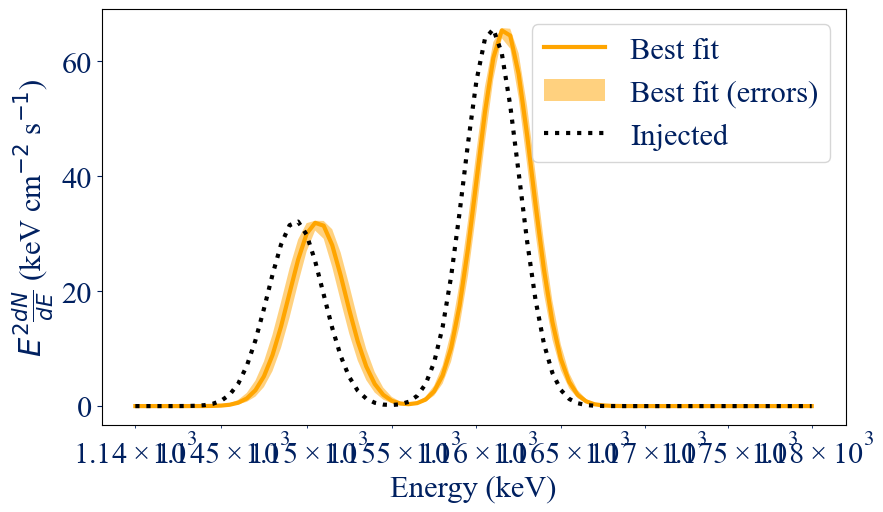

In [38]:
fig,ax = plt.subplots()

plt.plot(energy, energy*energy*flux_median, label = "Best fit")
plt.fill_between(energy, energy*energy*flux_lo, energy*energy*flux_hi, alpha = .5, label = "Best fit (errors)")
plt.plot(energy, energy*energy*flux_inj, color = 'black', ls = ":", label = "Injected")

plt.xscale("log")
# ax.set_yscale("log")

plt.xlabel("Energy (keV)")
plt.ylabel(r"$E^2 \frac{dN}{dE}$ (keV cm$^{-2}$ s$^{-1}$)")

plt.legend()
plt.show()

In [ ]:
def scan_log_likelihood(cosi, spectrum_attr1, values1, spectrum_attr2=None, values2=None):
    logL_results = []

    if spectrum_attr2 is None:
        # One-dimensional scan
        for val1 in values1:
            setattr(cosi._likelihood_model.source.spectrum.main.shape, spectrum_attr1, val1)
            logL = cosi.get_log_like()
            logL_results.append(logL)
        return np.array(logL_results)

    else:
        # Two-dimensional scan
        logL_grid = np.zeros((len(values1), len(values2)))
        for i, val1 in enumerate(values1):
            setattr(cosi._likelihood_model.source.spectrum.main.shape, spectrum_attr1, val1)
            for j, val2 in enumerate(values2):
                setattr(cosi._likelihood_model.source.spectrum.main.shape, spectrum_attr2, val2)
                logL_grid[i, j] = cosi.get_log_like()
        return logL_grid

def plot_logL_1d(values, logLs, xlabel, injected_value=None):
    plt.figure(figsize=(8, 5))
    plt.plot(values, logLs, lw=2)
    if injected_value is not None:
        plt.axvline(injected_value, ls=':', c='g', label='Injected')
    plt.axvline(values[np.nanargmax(logLs)], ls='--', label='Fit')
    plt.xlabel(xlabel)
    plt.ylabel("Log-Likelihood")
    plt.title(f"LogL vs. {xlabel} (Bgcnts {bgcounts})")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_logL_2d(values1, values2, logL_grid, xlabel, ylabel):
    plt.figure(figsize=(8, 6))
    plt.contourf(values1, values2, logL_grid.T, levels=50, cmap='viridis')
    plt.colorbar(label="Log-Likelihood")
    plt.xscale('log')
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(f"Log-Likelihood vs. {xlabel} and {ylabel}")
    plt.tight_layout()
    plt.show()

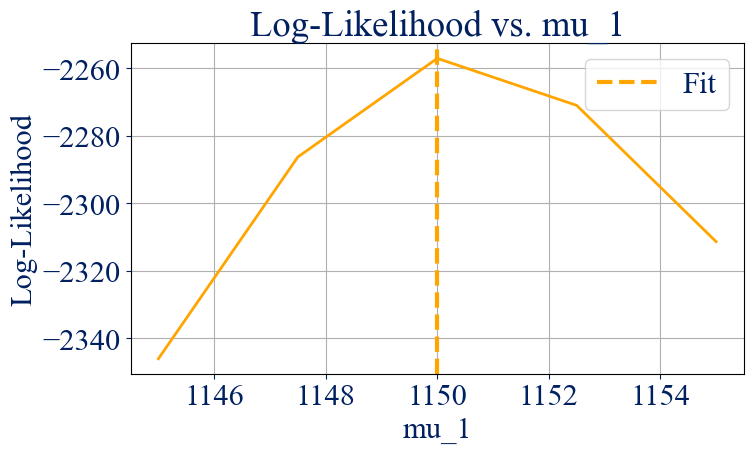

In [ ]:
F_values = np.geomspace(3e-4/10, 3e-4*10, 7)
mu_values = np.linspace(1145, 1155, 5)
sigma_values = np.linspace(1.1, 2.15, 7)

logL_grid = scan_log_likelihood(cosi, 'mu_1', mu_values)
plot_logL_1d(mu_values, logL_grid, xlabel='mu_1')

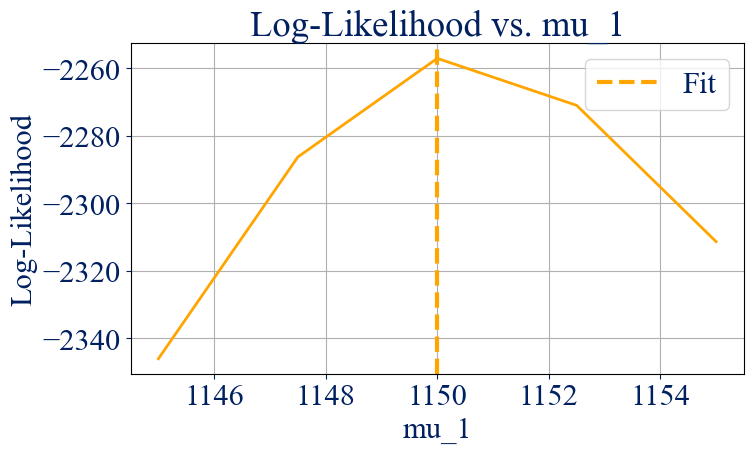

In [ ]:
F_values = np.geomspace(3e-4/10, 3e-4*10, 7)
mu_values = np.linspace(1145, 1155, 5)
sigma_values = np.linspace(1.1, 2.15, 7)

logL_grid = scan_log_likelihood(cosi, 'F_1', F_values)
plot_logL_1d(mu_values, logL_grid, xlabel='F_1')


WARNING IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.



14:20:34 WARNING   The current value of the parameter F (1.0) was above the new maximum 0.3.       ]8;id=60858;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=171136;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#794\794]8;;\

         WARNING   The current value of the parameter mu (0.0) was below the new minimum 1147.0.   ]8;id=748239;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=3526;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#720\720]8;;\

14:20:36 WARNING   The current value of the parameter F (1.0) was above the new maximum 0.3.       ]8;id=929251;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=353213;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#794\794]8;;\

         WARNING   The current value of the parameter mu (0.0) was below the new minimum 1147.0.   ]8;id=829979;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=151082;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#720\720]8;;\

...

14:22:35 WARNING   The current value of the parameter F (1.0) was above the new maximum 0.3.       ]8;id=861128;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=905008;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#794\794]8;;\

         WARNING   The current value of the parameter mu (0.0) was below the new minimum 1147.0.   ]8;id=885924;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=836250;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#720\720]8;;\

14:22:36 WARNING   The current value of the parameter F (1.0) was above the new maximum 0.3.       ]8;id=820905;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=311271;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#794\794]8;;\

         WARNING   The current value of the parameter mu (0.0) was below the new minimum 1147.0.   ]8;id=979066;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=830095;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#720\720]8;;\


WARNING IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.



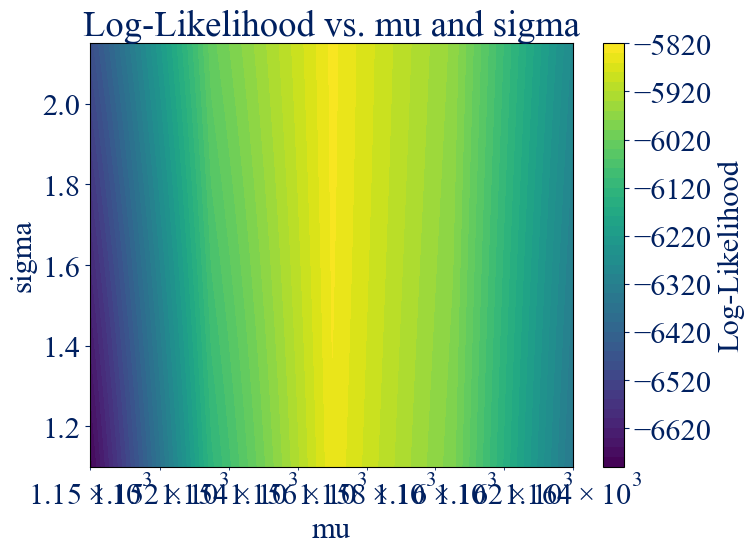

In [79]:
F_values = np.geomspace(3e-4/10, 3e-4*10, 7)
mu_values = np.linspace(1150, 1164, 5)
sigma_values = np.linspace(1.1, 2.15, 7)

logL_grid = scan_log_likelihood(cosi, "mu", mu_values, "sigma", sigma_values)
plot_logL_2d(mu_values, sigma_values, logL_grid, xlabel="mu", ylabel="sigma")

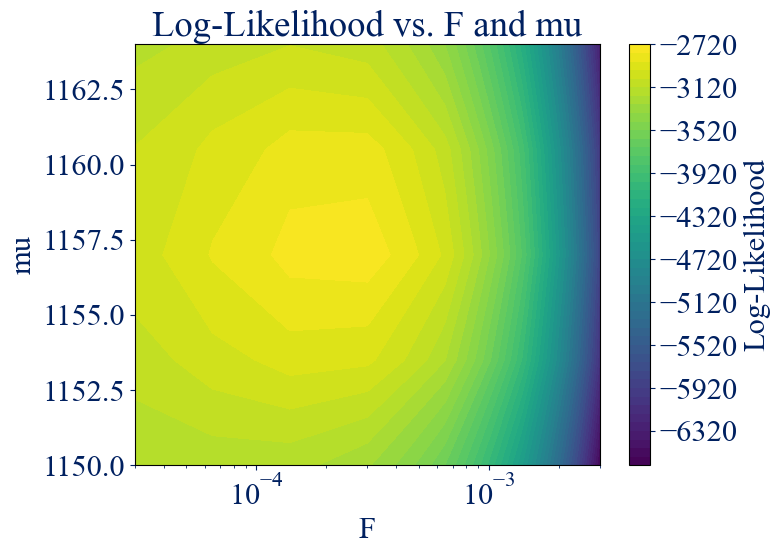

In [ ]:
F_values = np.geomspace(3e-4/10, 3e-4*10, 7)
mu_values = np.linspace(1150, 1164, 5)
sigma_values = np.linspace(1.1, 2.15, 7)

logL_grid = scan_log_likelihood(cosi, "F", F_values, "mu", mu_values)
plot_logL_2d(F_values, mu_values, logL_grid, xlabel="F", ylabel="mu")

#### Interpolation testing

In [29]:
target = {'Phi': 2.2923 * u.rad, 'Psi_sc': -12.9791 * u.deg, 'Chi_sc': -138.916 * u.deg}
get_interp_response(dr2, target)


WARNING UserWarning: len(target) != len(dr.axes)



<Quantity 4.78309265e-05 cm2>

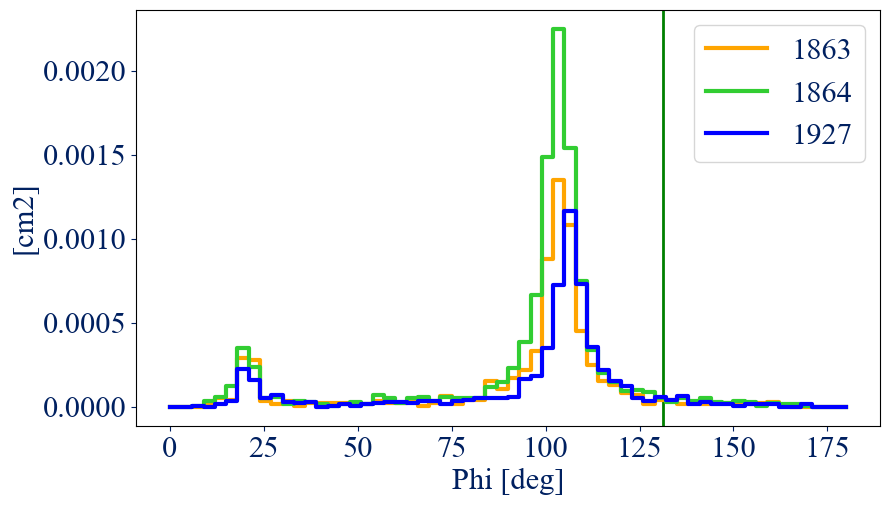

In [ ]:
ax, _ = dr2.slice[:, 1863].project('Phi').plot(label='1863')
dr2.slice[:, 1864].project('Phi').plot(ax=ax, label='1864')
dr2.slice[:, 1927].project('Phi').plot(ax=ax, label='1927')
plt.axvline(target['Phi'].to(u.deg).value, lw=2, c='g')
plt.legend()